In [1]:
#!pip -q install pylidc pydicom opencv-python-headless scipy pandas scikit-learn matplotlib

## 2. Imports and reproducibility

The revision uses a single fixed seed (`42`) everywhere. If we later run a seed-sensitivity
analysis, additional seeds will be defined explicitly rather than silently changing the split.

In [2]:
from pathlib import Path

RAW_DICOM_ROOT = Path(
    "/Volumes/Expansion/datasets/LIDC-IDRI/manifest-1600709154662/LIDC-IDRI"
)

PROJECT_ROOT = Path(
    "/Volumes/Expansion/PLOS_2D_UNet_Revision"
)

In [3]:
import sys
import numpy as np
import pandas as pd

print(sys.executable)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

/Volumes/Expansion/PLOS_2D_UNet_Revision/.venv/bin/python
NumPy: 1.26.4
pandas: 2.2.3


In [4]:
import os
import random
import json
import pydicom
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)

TensorFlow: 2.21.0
Seed: 42


## 3. Mount Google Drive and define **one** set of paths

Your Mac external drive (`/Volumes/Expansion/...`) is **not directly visible to Google Colab**.
If the full LIDC-IDRI dataset is uploaded/synced to Google Drive, point `RAW_DICOM_ROOT`
to that Drive folder.

Change only the two path variables below if your folder names differ.

In [5]:
METADATA_DIR = PROJECT_ROOT / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
def audit_lidc_dataset(root: Path):
    if not root.exists():
        raise FileNotFoundError(
            f"{root} does not exist. Upload/sync the dataset to Google Drive "
            "or change RAW_DICOM_ROOT."
        )

    patient_dirs = sorted([
        p for p in root.iterdir()
        if p.is_dir() and p.name.startswith("LIDC-IDRI-")
    ])

    rows = []
    total_dicom = 0

    for i, patient_dir in enumerate(patient_dirs, start=1):
        # TCIA files may be extensionless in some downloads, so first count .dcm;
        # if none are found, inspect all files with pydicom headers later.
        dcm_files = list(patient_dir.rglob("*.dcm"))
        total_dicom += len(dcm_files)

        rows.append({
            "patient_id": patient_dir.name,
            "patient_path": str(patient_dir),
            "dcm_files_with_extension": len(dcm_files),
        })

        if i % 100 == 0:
            print(f"Audited {i}/{len(patient_dirs)} patients...")

    inventory = pd.DataFrame(rows)
    inventory.to_csv(METADATA_DIR / "lidc_download_inventory.csv", index=False)

    print(f"\nPatients found: {len(patient_dirs):,}")
    print(f".dcm files found: {total_dicom:,}")
    print("Inventory saved to:",
          METADATA_DIR / "lidc_download_inventory.csv")
    return inventory

inventory = audit_lidc_dataset(RAW_DICOM_ROOT)
inventory.head()

Audited 100/1010 patients...
Audited 200/1010 patients...
Audited 300/1010 patients...
Audited 400/1010 patients...
Audited 500/1010 patients...
Audited 600/1010 patients...
Audited 700/1010 patients...
Audited 800/1010 patients...
Audited 900/1010 patients...
Audited 1000/1010 patients...

Patients found: 1,010
.dcm files found: 489,054
Inventory saved to: /Volumes/Expansion/PLOS_2D_UNet_Revision/metadata/lidc_download_inventory.csv


,patient_id,patient_path,dcm_files_with_extension
0,LIDC-IDRI-0001,/Volumes/Expansion/datasets/LIDC-IDRI/manifest...,270
1,LIDC-IDRI-0002,/Volumes/Expansion/datasets/LIDC-IDRI/manifest...,524
2,LIDC-IDRI-0003,/Volumes/Expansion/datasets/LIDC-IDRI/manifest...,290
3,LIDC-IDRI-0004,/Volumes/Expansion/datasets/LIDC-IDRI/manifest...,484
4,LIDC-IDRI-0005,/Volumes/Expansion/datasets/LIDC-IDRI/manifest...,270


## 5. Configure PyLIDC to use this DICOM directory

PyLIDC reads the DICOM root from `~/.pylidcrc`. The configuration is written **before**
importing `pylidc`, then the runtime imports PyLIDC against the correct root.

In [7]:
import pylidc as pl

scan = pl.query(pl.Scan).first()
clusters = scan.cluster_annotations()

print("Patient:", scan.patient_id)
print("Nodule clusters:", len(clusters))

for i, cluster in enumerate(clusters, start=1):
    print(f"Cluster {i}: {len(cluster)} radiologist annotation(s)")

/Volumes/Expansion/PLOS_2D_UNet_Revision/.venv/lib/python3.11/site-packages/pylidc/__init__.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as _pr


Patient: LIDC-IDRI-0078
Nodule clusters: 4
Cluster 1: 4 radiologist annotation(s)
Cluster 2: 4 radiologist annotation(s)
Cluster 3: 1 radiologist annotation(s)
Cluster 4: 4 radiologist annotation(s)


In [8]:
import numpy as np
import pandas as pd
import pylidc as pl

all_scans = pl.query(pl.Scan).all()

print("PyLIDC scans:", len(all_scans))

PyLIDC scans: 1018


In [9]:
annotation_rows = []

for i, scan in enumerate(all_scans, start=1):
    try:
        clusters = scan.cluster_annotations()

        n_clusters = len(clusters)
        n_annotations = sum(len(cluster) for cluster in clusters)

        annotation_rows.append({
            "patient_id": scan.patient_id,
            "scan_id": scan.id,
            "n_nodule_clusters": n_clusters,
            "n_annotations": n_annotations,
            "has_nodule_annotations": n_clusters > 0,
            "status": "OK",
            "error_message": ""
        })

        if i % 100 == 0:
            print(f"Checked {i}/{len(all_scans)} scans...")

    except Exception as e:
        annotation_rows.append({
            "patient_id": scan.patient_id,
            "scan_id": scan.id,
            "n_nodule_clusters": np.nan,
            "n_annotations": np.nan,
            "has_nodule_annotations": np.nan,
            "status": "ERROR",
            "error_message": str(e)
        })

        print(f"WARNING: {scan.patient_id}: {e}")

annotation_df = pd.DataFrame(annotation_rows)

print("\n=== LIDC-IDRI ANNOTATION AUDIT ===")
print("Total PyLIDC scans:", len(annotation_df))
print("Successful scans:", (annotation_df["status"] == "OK").sum())
print("Failed scans:", (annotation_df["status"] == "ERROR").sum())

ok_df = annotation_df[annotation_df["status"] == "OK"]

print(
    "Scans with nodule clusters:",
    ok_df["has_nodule_annotations"].sum()
)
print(
    "Scans without nodule clusters:",
    (~ok_df["has_nodule_annotations"].astype(bool)).sum()
)
print(
    "Total nodule clusters:",
    int(ok_df["n_nodule_clusters"].sum())
)
print(
    "Total radiologist annotations:",
    int(ok_df["n_annotations"].sum())
)

annotation_df.to_csv(
    METADATA_DIR / "lidc_annotation_inventory.csv",
    index=False
)

annotation_df.head()

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Checked 100/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Checked 200/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Checked 300/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Checked 400/1018 scans...
Failed to reduce all groups to <= 4 Annotations.
Some no

,patient_id,scan_id,n_nodule_clusters,n_annotations,has_nodule_annotations,status,error_message
0,LIDC-IDRI-0078,1,4,13,True,OK,
1,LIDC-IDRI-0069,2,3,9,True,OK,
2,LIDC-IDRI-0079,3,1,4,True,OK,
3,LIDC-IDRI-0101,4,1,2,True,OK,
4,LIDC-IDRI-0110,5,2,6,True,OK,


In [10]:
eligible = annotation_df[
    annotation_df["has_nodule_annotations"]
]

print(len(eligible))

883


In [11]:
# ============================================================
# 1. Build the eligible annotated cohort
# ============================================================

eligible_df = annotation_df[
    (annotation_df["status"] == "OK") &
    (annotation_df["has_nodule_annotations"] == True)
].copy()

print("Eligible annotated scans:", len(eligible_df))

# Confirm one row per scan.
assert eligible_df["scan_id"].is_unique

# Some patients may have more than one scan.
print("Unique eligible patients:", eligible_df["patient_id"].nunique())

Eligible annotated scans: 883
Unique eligible patients: 875


In [12]:
# ============================================================
# 2. Select the 500-scan study cohort reproducibly
# ============================================================

SEED = 42
COHORT_SIZE = 500

eligible_df = eligible_df.sort_values(
    ["patient_id", "scan_id"]
).reset_index(drop=True)

if len(eligible_df) < COHORT_SIZE:
    raise ValueError(
        f"Only {len(eligible_df)} eligible scans are available; "
        f"cannot select {COHORT_SIZE}."
    )

cohort_df = eligible_df.sample(
    n=COHORT_SIZE,
    random_state=SEED,
    replace=False
).sort_values(
    ["patient_id", "scan_id"]
).reset_index(drop=True)

print("Selected cohort scans:", len(cohort_df))
print("Selected unique patients:", cohort_df["patient_id"].nunique())

cohort_df.to_csv(
    METADATA_DIR / "selected_500_scan_cohort_seed42.csv",
    index=False
)

cohort_df.head()

Selected cohort scans: 500
Selected unique patients: 498


,patient_id,scan_id,n_nodule_clusters,n_annotations,has_nodule_annotations,status,error_message
0,LIDC-IDRI-0001,12,1,4,True,OK,
1,LIDC-IDRI-0003,14,4,13,True,OK,
2,LIDC-IDRI-0004,15,1,4,True,OK,
3,LIDC-IDRI-0006,17,4,8,True,OK,
4,LIDC-IDRI-0007,18,2,5,True,OK,


In [13]:
# ============================================================
# 3. Create a patient-level 70/15/15 split
# ============================================================

rng = np.random.default_rng(SEED)

unique_patients = np.array(
    sorted(cohort_df["patient_id"].unique())
)

rng.shuffle(unique_patients)

n_patients = len(unique_patients)

n_train = int(round(n_patients * 0.70))
n_val = int(round(n_patients * 0.15))

train_patients = unique_patients[:n_train]
val_patients = unique_patients[n_train:n_train + n_val]
test_patients = unique_patients[n_train + n_val:]

# Safety checks
assert len(set(train_patients) & set(val_patients)) == 0
assert len(set(train_patients) & set(test_patients)) == 0
assert len(set(val_patients) & set(test_patients)) == 0

split_map = {
    **{pid: "train" for pid in train_patients},
    **{pid: "validation" for pid in val_patients},
    **{pid: "test" for pid in test_patients},
}

cohort_df["split"] = cohort_df["patient_id"].map(split_map)

print("\n=== PATIENT-LEVEL SPLIT ===")
print(cohort_df.groupby("split")["patient_id"].nunique())
print("\nScans per split:")
print(cohort_df["split"].value_counts())

assert cohort_df["split"].notna().all()


=== PATIENT-LEVEL SPLIT ===
split
test           74
train         349
validation     75
Name: patient_id, dtype: int64

Scans per split:
split
train         350
validation     76
test           74
Name: count, dtype: int64


In [14]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/Volumes/Expansion/PLOS_2D_UNet_Revision"
)

SPLITS_DIR = PROJECT_ROOT / "splits"
METADATA_DIR = PROJECT_ROOT / "metadata"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "processed"
MASKS_DIR = PROJECT_ROOT / "masks"

for folder in [
    SPLITS_DIR,
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    PROCESSED_DIR,
    MASKS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Splits folder:", SPLITS_DIR)
print("Exists:", SPLITS_DIR.exists())

Splits folder: /Volumes/Expansion/PLOS_2D_UNet_Revision/splits
Exists: True


In [15]:
# ============================================================
# 4. Save the reproducible split files
# ============================================================

split_columns = [
    "patient_id",
    "scan_id",
    "n_nodule_clusters",
    "n_annotations",
    "split"
]

cohort_split_df = cohort_df[split_columns].sort_values(
    ["split", "patient_id", "scan_id"]
)

cohort_split_df.to_csv(
    SPLITS_DIR / "patient_level_split_seed42.csv",
    index=False
)

for split_name in ["train", "validation", "test"]:
    split_subset = cohort_split_df[
        cohort_split_df["split"] == split_name
    ]

    split_subset.to_csv(
        SPLITS_DIR / f"{split_name}_scans_seed42.csv",
        index=False
    )

print(
    "Saved:",
    SPLITS_DIR / "patient_level_split_seed42.csv"
)

Saved: /Volumes/Expansion/PLOS_2D_UNet_Revision/splits/patient_level_split_seed42.csv


In [16]:
# ============================================================
# 5. Explicit leakage audit
# ============================================================

patient_split_counts = (
    cohort_split_df
    .groupby("patient_id")["split"]
    .nunique()
)

leaking_patients = patient_split_counts[
    patient_split_counts > 1
]

print("Patients appearing in multiple splits:",
      len(leaking_patients))

assert len(leaking_patients) == 0

print("Patient-level leakage check: PASSED")

Patients appearing in multiple splits: 0
Patient-level leakage check: PASSED


In [17]:
# ============================================================
# 5.a inspect the actual split sizest
# ============================================================


print("Unique patients per split:")
print(
    cohort_split_df
    .groupby("split")["patient_id"]
    .nunique()
)

print("\nScans per split:")
print(
    cohort_split_df["split"]
    .value_counts()
)

print("\nNodule clusters per split:")
print(
    cohort_split_df
    .groupby("split")["n_nodule_clusters"]
    .sum()
)

print("\nRadiologist annotations per split:")
print(
    cohort_split_df
    .groupby("split")["n_annotations"]
    .sum()
)

Unique patients per split:
split
test           74
train         349
validation     75
Name: patient_id, dtype: int64

Scans per split:
split
train         350
validation     76
test           74
Name: count, dtype: int64

Nodule clusters per split:
split
test           222
train         1061
validation     239
Name: n_nodule_clusters, dtype: int64

Radiologist annotations per split:
split
test           570
train         2734
validation     597
Name: n_annotations, dtype: int64


In [18]:
split_summary = (
    cohort_split_df
    .groupby("split")
    .agg(
        n_scans=("scan_id", "count"),
        n_patients=("patient_id", "nunique"),
        total_nodule_clusters=("n_nodule_clusters", "sum"),
        total_annotations=("n_annotations", "sum"),
        mean_nodules_per_scan=("n_nodule_clusters", "mean"),
    )
    .reset_index()
)

split_summary.to_csv(
    SPLITS_DIR / "split_summary_seed42.csv",
    index=False
)

split_summary

,split,n_scans,n_patients,total_nodule_clusters,total_annotations,mean_nodules_per_scan
0,test,74,74,222,570,3.000000
1,train,350,349,1061,2734,3.031429
2,validation,76,75,239,597,3.144737


## single-patient preprocessing smoke test

In [19]:
from pylidc.utils import consensus
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [20]:
scan_by_id = {
    scan.id: scan
    for scan in pl.query(pl.Scan).all()
}

test_row = cohort_split_df.iloc[0]
test_scan_id = int(test_row["scan_id"])
test_patient_id = test_row["patient_id"]

test_scan = scan_by_id[test_scan_id]

print("Test patient:", test_patient_id)
print("Scan ID:", test_scan_id)
print("Nodule clusters:", test_row["n_nodule_clusters"])

Test patient: LIDC-IDRI-0010
Scan ID: 21
Nodule clusters: 3


In [21]:
CONSENSUS_LEVEL = 0.50

volume_hu = test_scan.to_volume().astype(np.float32)
full_mask = np.zeros(volume_hu.shape, dtype=np.uint8)

clusters = test_scan.cluster_annotations()

for cluster_index, annotations in enumerate(clusters, start=1):
    consensus_mask, consensus_bbox, masks = consensus(
        annotations,
        clevel=CONSENSUS_LEVEL,
        pad=None
    )

    target_region = full_mask[consensus_bbox]

    if target_region.shape != consensus_mask.shape:
        raise ValueError(
            f"Shape mismatch in cluster {cluster_index}: "
            f"target={target_region.shape}, "
            f"consensus={consensus_mask.shape}"
        )

    full_mask[consensus_bbox] = np.logical_or(
        target_region,
        consensus_mask
    ).astype(np.uint8)

print("CT volume shape:", volume_hu.shape)
print("Mask volume shape:", full_mask.shape)
print("Positive mask voxels:", int(full_mask.sum()))

assert volume_hu.shape == full_mask.shape
assert full_mask.sum() > 0

print("Consensus mask test: PASSED")

Loading dicom files ... This may take a moment.
CT volume shape: (512, 512, 277)
Mask volume shape: (512, 512, 277)
Positive mask voxels: 306
Consensus mask test: PASSED


In [22]:
HU_WINDOW_CENTER = -600
HU_WINDOW_WIDTH = 1500

def apply_hu_window(volume, center=-600, width=1500):
    lower = center - width / 2
    upper = center + width / 2

    windowed = np.clip(
        volume.astype(np.float32),
        lower,
        upper
    )

    normalized = (
        windowed - lower
    ) / (
        upper - lower
    )

    return normalized.astype(np.float32)

volume_normalized = apply_hu_window(
    volume_hu,
    center=HU_WINDOW_CENTER,
    width=HU_WINDOW_WIDTH
)

print("Normalized minimum:", volume_normalized.min())
print("Normalized maximum:", volume_normalized.max())

Normalized minimum: 0.0
Normalized maximum: 1.0


In [23]:
### Identify the positive slices ####

slice_mask_areas = full_mask.sum(axis=(0, 1))

positive_slice_indices = np.flatnonzero(
    slice_mask_areas > 0
)

print("Total CT slices:", volume_hu.shape[2])
print("Positive nodule slices:", len(positive_slice_indices))
print(
    "Positive slice range:",
    positive_slice_indices.min(),
    "to",
    positive_slice_indices.max()
)

Total CT slices: 277
Positive nodule slices: 13
Positive slice range: 67 to 211


In [24]:
### Choose the slice containing the largest mask

largest_slice_index = int(
    np.argmax(slice_mask_areas)
)

print(
    "Slice with largest nodule area:",
    largest_slice_index
)
print(
    "Mask pixels on that slice:",
    int(slice_mask_areas[largest_slice_index])
)

Slice with largest nodule area: 210
Mask pixels on that slice: 48


In [25]:
### Resize the image and mask correctly

TARGET_SIZE = (256, 256)

ct_slice = volume_normalized[
    :, :, largest_slice_index
]

mask_slice = full_mask[
    :, :, largest_slice_index
]

ct_resized = cv2.resize(
    ct_slice,
    TARGET_SIZE,
    interpolation=cv2.INTER_LINEAR
).astype(np.float32)

mask_resized = cv2.resize(
    mask_slice,
    TARGET_SIZE,
    interpolation=cv2.INTER_NEAREST
)

mask_resized = (
    mask_resized > 0
).astype(np.uint8)

print("Original CT slice:", ct_slice.shape)
print("Original mask:", mask_slice.shape)
print("Resized CT:", ct_resized.shape)
print("Resized mask:", mask_resized.shape)
print("Mask values:", np.unique(mask_resized))

assert ct_resized.shape == mask_resized.shape
assert set(np.unique(mask_resized)).issubset({0, 1})

print("Resize test: PASSED")

Original CT slice: (512, 512)
Original mask: (512, 512)
Resized CT: (256, 256)
Resized mask: (256, 256)
Mask values: [0 1]
Resize test: PASSED


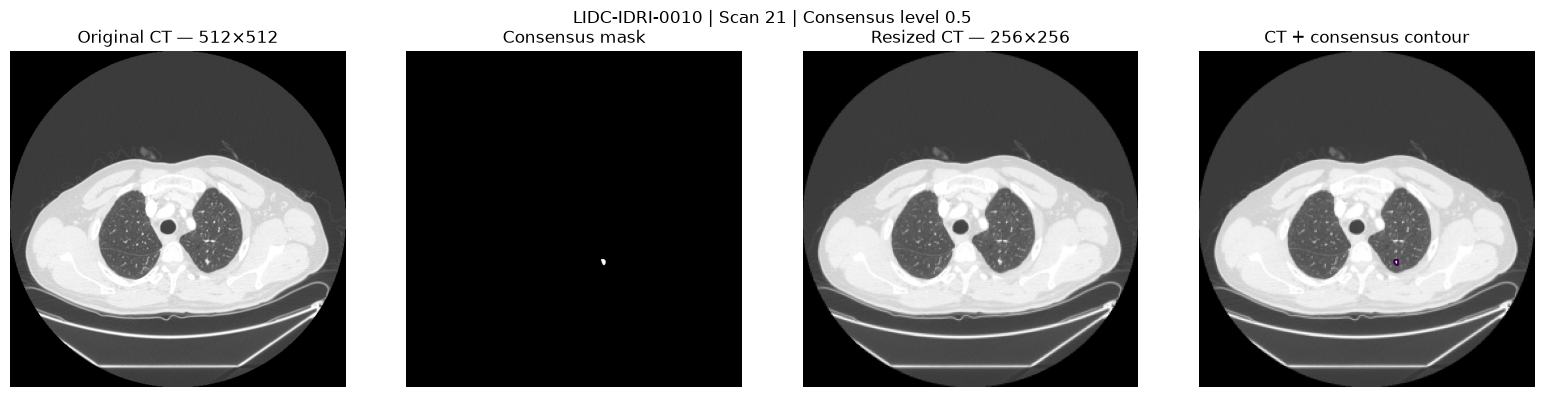

Figure saved to: /Volumes/Expansion/PLOS_2D_UNet_Revision/figures/LIDC-IDRI-0010_consensus_smoke_test.png


In [26]:
# Produce the first valid qualitative figure

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

axes[0].imshow(
    ct_slice,
    cmap="gray"
)
axes[0].set_title("Original CT — 512×512")

axes[1].imshow(
    mask_slice,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[1].set_title("Consensus mask")

axes[2].imshow(
    ct_resized,
    cmap="gray"
)
axes[2].set_title("Resized CT — 256×256")

axes[3].imshow(
    ct_resized,
    cmap="gray"
)
axes[3].contour(
    mask_resized,
    levels=[0.5],
    linewidths=1.5
)
axes[3].set_title("CT + consensus contour")

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"{test_patient_id} | Scan {test_scan_id} | "
    f"Consensus level {CONSENSUS_LEVEL}"
)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    f"{test_patient_id}_consensus_smoke_test.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

In [27]:
### Save a one-ptient processed test file
processed_test_path = (
    PROCESSED_DIR /
    f"{test_patient_id}_scan{test_scan_id}_smoke_test.npz"
)

np.savez_compressed(
    processed_test_path,
    volume_hu=volume_hu,
    volume_normalized=volume_normalized,
    consensus_mask=full_mask,
    positive_slice_indices=positive_slice_indices,
    consensus_level=np.array(
        CONSENSUS_LEVEL,
        dtype=np.float32
    ),
    patient_id=np.array(test_patient_id),
    scan_id=np.array(test_scan_id)
)

print("Processed smoke-test file saved to:")
print(processed_test_path)

Processed smoke-test file saved to:
/Volumes/Expansion/PLOS_2D_UNet_Revision/processed/LIDC-IDRI-0010_scan21_smoke_test.npz


In [28]:
# ============================================================
# Build complete processed dataset
# ============================================================

from pathlib import Path
import cv2
import numpy as np
import pandas as pd

from pylidc.utils import consensus

CONSENSUS_LEVEL = 0.50
TARGET_SIZE = (256, 256)

processed_rows = []

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Building processed dataset")
print("=" * 60)

for idx, row in cohort_df.iterrows():

    patient_id = row.patient_id
    scan_id = row.scan_id
    split = row.split

    try:

        #######################################################
        # Load scan
        #######################################################

        scan = pl.query(pl.Scan).filter(pl.Scan.id == scan_id).first()

        if scan is None:
            raise RuntimeError(f"Scan {scan_id} not found.")

        #######################################################
        # CT volume
        #######################################################

        volume_hu = scan.to_volume().astype(np.float32)

        #######################################################
        # Empty consensus mask
        #######################################################

        mask = np.zeros(volume_hu.shape, dtype=np.uint8)

        #######################################################
        # Consensus masks
        #######################################################

        clusters = scan.cluster_annotations()

        for annotations in clusters:

            consensus_mask, bbox, _ = consensus(
                annotations,
                clevel=CONSENSUS_LEVEL,
                pad=None
            )

            target = mask[bbox]

            target[:] = np.logical_or(
                target,
                consensus_mask
            ).astype(np.uint8)

        #######################################################
        # Resize every slice
        #######################################################

        resized_volume = np.empty(
            (TARGET_SIZE[0], TARGET_SIZE[1], volume_hu.shape[2]),
            dtype=np.float32,
        )

        resized_mask = np.empty(
            (TARGET_SIZE[0], TARGET_SIZE[1], mask.shape[2]),
            dtype=np.uint8,
        )

        for z in range(volume_hu.shape[2]):

            resized_volume[:, :, z] = cv2.resize(
                volume_hu[:, :, z],
                TARGET_SIZE,
                interpolation=cv2.INTER_LINEAR,
            )

            resized_mask[:, :, z] = cv2.resize(
                mask[:, :, z],
                TARGET_SIZE,
                interpolation=cv2.INTER_NEAREST,
            )

        #######################################################
        # Ensure binary
        #######################################################

        resized_mask = (resized_mask > 0).astype(np.uint8)

        #######################################################
        # Positive slices
        #######################################################

        positive_slice_indices = np.where(
            resized_mask.sum(axis=(0, 1)) > 0
        )[0]

        #######################################################
        # Normalize CT
        #######################################################

        volume_normalized = np.clip(
            resized_volume,
            -1000,
            400,
        )

        volume_normalized = (
            volume_normalized + 1000
        ) / 1400.0

        volume_normalized = volume_normalized.astype(np.float32)

        #######################################################
        # Save
        #######################################################

        output_file = (
            PROCESSED_DIR
            / f"{patient_id}_scan{scan_id}.npz"
        )

        np.savez_compressed(
            output_file,
            volume_hu=resized_volume,
            volume_normalized=volume_normalized,
            consensus_mask=resized_mask,
            positive_slice_indices=positive_slice_indices,
            consensus_level=np.array(
                CONSENSUS_LEVEL,
                dtype=np.float32,
            ),
            patient_id=np.array(patient_id),
            scan_id=np.array(scan_id),
            split=np.array(split),
        )

        processed_rows.append({

            "patient_id": patient_id,
            "scan_id": scan_id,
            "split": split,

            "status": "OK",

            "n_clusters": len(clusters),

            "positive_slices":
                len(positive_slice_indices),

            "mask_voxels":
                int(resized_mask.sum()),

            "shape":
                resized_volume.shape

        })

    except Exception as e:

        processed_rows.append({

            "patient_id": patient_id,
            "scan_id": scan_id,
            "split": split,

            "status": "ERROR",

            "error": str(e)

        })

    ###########################################################
    # Progress
    ###########################################################

    if (idx + 1) % 25 == 0:

        print(
            f"{idx+1}/{len(cohort_df)} processed..."
        )

print("\nFinished.")

Building processed dataset
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom

In [29]:
processed_df = pd.DataFrame(processed_rows)

processed_df.to_csv(
    METADATA_DIR / "processed_dataset_report.csv",
    index=False
)

print("=" * 60)
print("PROCESSING SUMMARY")
print("=" * 60)

print("Total scans:", len(processed_df))
print("Successful:", (processed_df.status == "OK").sum())
print("Failed:", (processed_df.status == "ERROR").sum())

ok = processed_df[processed_df.status == "OK"]

print()

print("Average positive slices:",
      ok.positive_slices.mean())

print("Median positive slices:",
      ok.positive_slices.median())

print("Average mask voxels:",
      ok.mask_voxels.mean())

print()

print(ok.groupby("split").size())

print("=" * 60)

PROCESSING SUMMARY
Total scans: 500
Successful: 500
Failed: 0

Average positive slices: 15.432
Median positive slices: 11.0
Average mask voxels: 594.964

split
test           74
train         350
validation     76
dtype: int64


In [35]:
print("cohort_df:", len(cohort_df))
print("annotation_df:", len(annotation_df))
print("ok_df:", len(ok_df))

cohort_df: 500
annotation_df: 1018
ok_df: 1018


In [36]:
print(cohort_df.head())

       patient_id  scan_id  n_nodule_clusters  n_annotations  \
0  LIDC-IDRI-0001       12                  1              4   
1  LIDC-IDRI-0003       14                  4             13   
2  LIDC-IDRI-0004       15                  1              4   
3  LIDC-IDRI-0006       17                  4              8   
4  LIDC-IDRI-0007       18                  2              5   

   has_nodule_annotations status error_message       split  
0                    True     OK                     train  
1                    True     OK                validation  
2                    True     OK                     train  
3                    True     OK                     train  
4                    True     OK                     train  


In [39]:
smoke_test_file = (
    PROCESSED_DIR /
    "LIDC-IDRI-0010_scan21_smoke_test.npz"
)

if smoke_test_file.exists():
    smoke_test_file.unlink()
    print("Deleted:", smoke_test_file)
else:
    print("Smoke-test file not found.")

Deleted: /Volumes/Expansion/PLOS_2D_UNet_Revision/processed/LIDC-IDRI-0010_scan21_smoke_test.npz


In [40]:
expected = len(cohort_df)
generated = len(list(PROCESSED_DIR.glob("*.npz")))

print("Expected:", expected)
print("Generated:", generated)

assert expected == generated

Expected: 500
Generated: 500


In [41]:
production_files = [
    p for p in PROCESSED_DIR.glob("*.npz")
    if "smoke_test" not in p.name
]

print("Production files:", len(production_files))
assert len(production_files) == len(cohort_df)

Production files: 500


In [42]:
# ============================================================
# Build slice-level index
# ============================================================

slice_rows = []

for i, row in cohort_df.iterrows():
    patient_id = row["patient_id"]
    scan_id = int(row["scan_id"])
    split = row["split"]

    npz_path = (
        PROCESSED_DIR /
        f"{patient_id}_scan{scan_id}.npz"
    )

    if not npz_path.exists():
        raise FileNotFoundError(npz_path)

    with np.load(npz_path) as data:
        masks = data["consensus_mask"]

        if masks.ndim != 3:
            raise ValueError(
                f"{npz_path.name}: expected 3D mask, got {masks.shape}"
            )

        n_slices = masks.shape[2]
        mask_pixels_per_slice = masks.sum(axis=(0, 1))

        for z in range(n_slices):
            mask_pixels = int(mask_pixels_per_slice[z])

            slice_rows.append({
                "patient_id": patient_id,
                "scan_id": scan_id,
                "split": split,
                "npz_path": str(npz_path),
                "slice_index": z,
                "is_positive": mask_pixels > 0,
                "mask_pixels": mask_pixels,
            })

    if (i + 1) % 50 == 0:
        print(f"Indexed {i + 1}/{len(cohort_df)} scans...")

slice_index_df = pd.DataFrame(slice_rows)

slice_index_path = (
    METADATA_DIR /
    "slice_level_index_seed42.csv"
)

slice_index_df.to_csv(
    slice_index_path,
    index=False
)

print("\nSlice-level index saved to:")
print(slice_index_path)

print("\nTotal slices:", len(slice_index_df))
print(
    "Positive slices:",
    int(slice_index_df["is_positive"].sum())
)
print(
    "Negative slices:",
    int((~slice_index_df["is_positive"]).sum())
)

Indexed 50/500 scans...
Indexed 100/500 scans...
Indexed 150/500 scans...
Indexed 200/500 scans...
Indexed 250/500 scans...
Indexed 300/500 scans...
Indexed 350/500 scans...
Indexed 400/500 scans...
Indexed 450/500 scans...
Indexed 500/500 scans...

Slice-level index saved to:
/Volumes/Expansion/PLOS_2D_UNet_Revision/metadata/slice_level_index_seed42.csv

Total slices: 119816
Positive slices: 7716
Negative slices: 112100


In [43]:
slice_summary = (
    slice_index_df
    .groupby("split")
    .agg(
        total_slices=("slice_index", "count"),
        positive_slices=("is_positive", "sum"),
        unique_patients=("patient_id", "nunique"),
        unique_scans=("scan_id", "nunique"),
    )
)

slice_summary["negative_slices"] = (
    slice_summary["total_slices"]
    - slice_summary["positive_slices"]
)

slice_summary["positive_fraction"] = (
    slice_summary["positive_slices"]
    / slice_summary["total_slices"]
)

slice_summary.to_csv(
    METADATA_DIR / "slice_level_summary_seed42.csv"
)

slice_summary

,total_slices,positive_slices,unique_patients,unique_scans,negative_slices,positive_fraction
split,,,,,,
test,16893,1142,74,74,15751,0.067602
train,85439,5379,349,350,80060,0.062957
validation,17484,1195,75,76,16289,0.068348


In [44]:
patient_split_counts = (
    slice_index_df
    .groupby("patient_id")["split"]
    .nunique()
)

leaking_patients = patient_split_counts[
    patient_split_counts > 1
]

print(
    "Patients appearing in multiple slice-level splits:",
    len(leaking_patients)
)

assert len(leaking_patients) == 0

print("Slice-level leakage check: PASSED")

Patients appearing in multiple slice-level splits: 0
Slice-level leakage check: PASSED


In [45]:
# ============================================================
# SECTION 6
# TensorFlow Data Pipeline
# ============================================================

In [46]:
import tensorflow as tf
import numpy as np
import pandas as pd

from pathlib import Path

In [47]:
### 6.2 Load the slice index

slice_index_path = (
    METADATA_DIR /
    "slice_level_index_seed42.csv"
)

slice_index_df = pd.read_csv(slice_index_path)

print(slice_index_df.head())
print(len(slice_index_df))

       patient_id  scan_id  split  \
0  LIDC-IDRI-0001       12  train   
1  LIDC-IDRI-0001       12  train   
2  LIDC-IDRI-0001       12  train   
3  LIDC-IDRI-0001       12  train   
4  LIDC-IDRI-0001       12  train   

                                            npz_path  slice_index  \
0  /Volumes/Expansion/PLOS_2D_UNet_Revision/proce...            0   
1  /Volumes/Expansion/PLOS_2D_UNet_Revision/proce...            1   
2  /Volumes/Expansion/PLOS_2D_UNet_Revision/proce...            2   
3  /Volumes/Expansion/PLOS_2D_UNet_Revision/proce...            3   
4  /Volumes/Expansion/PLOS_2D_UNet_Revision/proce...            4   

   is_positive  mask_pixels  
0        False            0  
1        False            0  
2        False            0  
3        False            0  
4        False            0  
119816


In [48]:
### 6.3 Split into train/validation/test

train_df = slice_index_df[
    slice_index_df["split"] == "train"
].reset_index(drop=True)

val_df = slice_index_df[
    slice_index_df["split"] == "validation"
].reset_index(drop=True)

test_df = slice_index_df[
    slice_index_df["split"] == "test"
].reset_index(drop=True)

print(len(train_df))
print(len(val_df))
print(len(test_df))

85439
17484
16893


In [49]:
### 6.4 Positive/negative statistics

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    positives = df["is_positive"].sum()

    print(
        f"{name}: "
        f"{positives}/{len(df)} "
        f"({100*positives/len(df):.2f}%)"
    )

Train: 5379/85439 (6.30%)
Validation: 1195/17484 (6.83%)
Test: 1142/16893 (6.76%)


In [50]:
### 6.5 Create a slice loader

def load_slice(row):

    with np.load(row["npz_path"]) as data:

        image = data["volume_normalized"][
            :, :, row["slice_index"]
        ]

        mask = data["consensus_mask"][
            :, :, row["slice_index"]
        ]

    image = image.astype(np.float32)
    mask = mask.astype(np.float32)

    image = image[..., np.newaxis]
    mask = mask[..., np.newaxis]

    return image, mask

In [51]:
### 6.6 Smoke test

image, mask = load_slice(train_df.iloc[0])

print(image.shape)
print(mask.shape)

print(image.dtype)
print(mask.dtype)

print(mask.max())
print(mask.min())

(256, 256, 1)
(256, 256, 1)
float32
float32
0.0
0.0


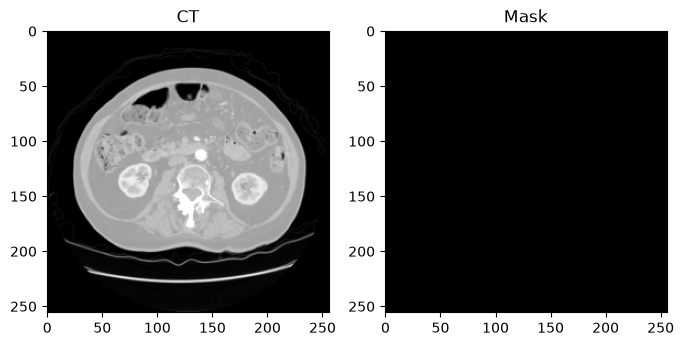

In [52]:
### Display one example

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(image[:,:,0], cmap="gray")
ax[0].set_title("CT")

ax[1].imshow(mask[:,:,0], cmap="gray")
ax[1].set_title("Mask")

plt.show()

In [53]:
row = train_df.iloc[0]

print(row)

patient_id                                        LIDC-IDRI-0001
scan_id                                                       12
split                                                      train
npz_path       /Volumes/Expansion/PLOS_2D_UNet_Revision/proce...
slice_index                                                    0
is_positive                                                False
mask_pixels                                                    0
Name: 0, dtype: object


In [55]:
positive_row = train_df[
    train_df["is_positive"]
].iloc[0]

image, mask = load_slice(positive_row)

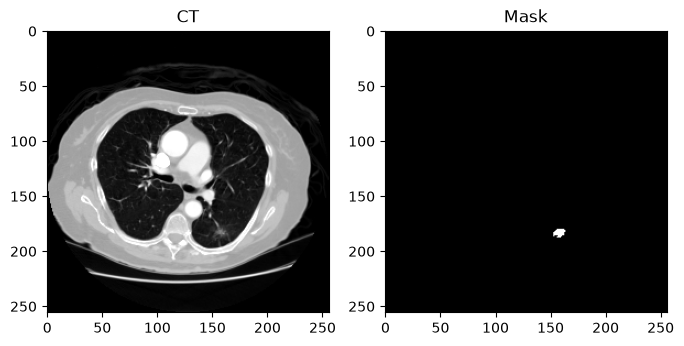

In [56]:
fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(image[:,:,0], cmap="gray")
ax[0].set_title("CT")

ax[1].imshow(mask[:,:,0], cmap="gray")
ax[1].set_title("Mask")

plt.show()

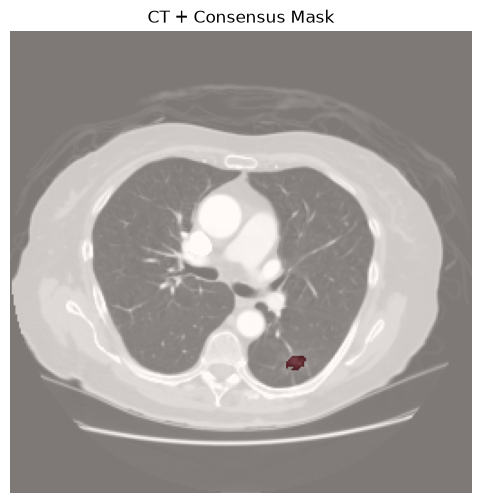

In [57]:
fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(image[:, :, 0], cmap="gray")
ax.imshow(mask[:, :, 0], cmap="Reds", alpha=0.5)

ax.set_title("CT + Consensus Mask")
ax.axis("off")

plt.show()

In [58]:
train_df["is_positive"].value_counts()

is_positive
False    80060
True      5379
Name: count, dtype: int64